## **Multinomial Logistic Regression** 

#### **Project:** 
   
    - News Article Category Classification 

#### **Problem Statement:** 
    
    - Classify news articles into sports, politics, business, or technology categories.

In [17]:
# Step No 1 : Importing the required Libraries 

# Numerical Libraries 
import numpy as np

# Data Manipulation and Cleaning Libraries
import pandas as pd 

# Data Visualization Libraries 
import matplotlib.pyplot as plt

# Advanced Visualization Libraries
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split

# Text vectorization 
from sklearn.feature_extraction.text import CountVectorizer

# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Model Evaluation Metrics
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score

In [18]:
# Step No 2 : Loading the Dataset 
df = pd.read_csv("bbc-text.csv")

In [19]:
# Step No 3 : Understanding the dataset 

# Display first rows 
print(df.head())

# Display Shape of the datast 
print(df.shape)

# Display the dataset information 
print(df.info())

# Display the statistical summary of the dataset 
print(df.describe()) 

        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...
(2225, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None
       category                                               text
count      2225                                               2225
unique        5                                               2126
top       sport  kennedy questions trust of blair lib dem leade...
freq      

In [20]:
# Step No 4 : Data Cleaning and Preprocessing

# Check for missing values 
print(df.isnull().sum())

# Check for duplicate values 
print(df.duplicated().sum())

# Remove duplicate values 
print(df.drop_duplicates(inplace=True))

category    0
text        0
dtype: int64
99
None


In [21]:
# Step No 5 : Rename Columns 
#Rename dataset column 
df = df.rename(columns={
    "category": "Category",
    "text": "Article"
})

In [22]:
# Step No 6 : Features and Target Variable 

# Define input variable 
X = df["Article"]

# Define target variable
y = df["Category"] 

In [23]:
# Step No 7 : Text Vectorization 

# Create CountVectorizer object 
vectorizer = CountVectorizer()

# Convert text data into numeric vectors
X_vectorized = vectorizer.fit_transform(X)

In [24]:
# Step No 8 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(
    X_vectorized , y , test_size = 0.2 , random_state = 42 
)

In [25]:
# Step No 9 : Initailize the Multinomial logistic regression model

# Create Logistic Regression Model 
model = LogisticRegression(
    multi_class = "multinomial",
    solver = "lbfgs",
    max_iter = 1000
)

In [26]:
# Step No 10 : Model Training 

# Train Model 
model.fit(X_train , y_train)


C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [27]:
# Step No 11 : Prediction 

# Predict categories 
y_pred = model.predict(X_test)

# Display predicted categories 
print("Predicted Categories : ")
print(y_pred)

Predicted Categories : 
['politics' 'business' 'sport' 'sport' 'business' 'entertainment' 'tech'
 'sport' 'politics' 'tech' 'sport' 'politics' 'sport' 'tech' 'business'
 'business' 'sport' 'politics' 'politics' 'business' 'tech' 'business'
 'sport' 'politics' 'politics' 'business' 'entertainment' 'sport' 'sport'
 'entertainment' 'business' 'politics' 'sport' 'entertainment' 'sport'
 'sport' 'tech' 'sport' 'sport' 'entertainment' 'tech' 'sport' 'politics'
 'entertainment' 'business' 'politics' 'sport' 'tech' 'business'
 'entertainment' 'sport' 'politics' 'business' 'politics' 'sport'
 'business' 'tech' 'business' 'politics' 'business' 'entertainment'
 'politics' 'sport' 'business' 'politics' 'tech' 'sport' 'entertainment'
 'tech' 'sport' 'entertainment' 'sport' 'tech' 'entertainment' 'business'
 'sport' 'politics' 'business' 'tech' 'business' 'politics' 'sport'
 'sport' 'tech' 'sport' 'business' 'sport' 'politics' 'entertainment'
 'business' 'politics' 'sport' 'politics' 'sport' 'tech' 

In [28]:
# Step No 12 : Model Evaluation 

# Calculate accuracy score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Calculate classification report 
print("Classification Report : ")
print(classification_report (y_test , y_pred ))

# Calculate confusion matrix
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred ))

Accuracy Score : 
0.9671361502347418
Classification Report : 
               precision    recall  f1-score   support

     business       0.95      0.96      0.95        96
entertainment       0.96      0.99      0.97        68
     politics       0.95      0.95      0.95        83
        sport       0.98      1.00      0.99       109
         tech       1.00      0.93      0.96        70

     accuracy                           0.97       426
    macro avg       0.97      0.96      0.97       426
 weighted avg       0.97      0.97      0.97       426

Confusion Matrix : 
[[ 92   1   3   0   0]
 [  0  67   1   0   0]
 [  1   1  79   2   0]
 [  0   0   0 109   0]
 [  4   1   0   0  65]]


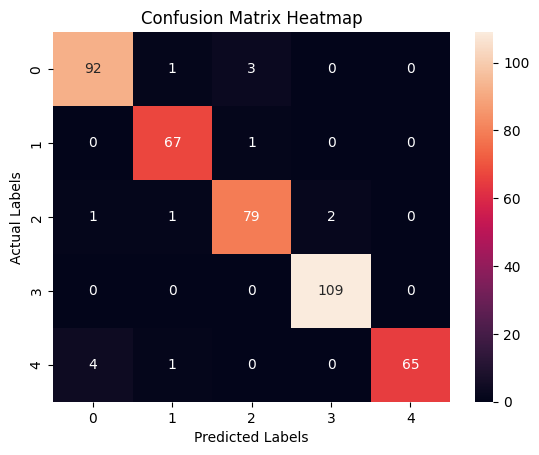

In [29]:
# Step No 13 : Visualization of Confusion Matrix 

# Plot confusion matrix heatmap 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot = True , 
    fmt = "d"
)

# Set Plot Title 
plt.title("Confusion Matrix Heatmap")

# Set X-axis label
plt.xlabel("Predicted Labels")

# Set Y-axis Label
plt.ylabel("Actual Labels")

# Save figure 
plt.savefig("images/confusion_matrix_heatmap(mulatinomial_logistic_regression).png")

# Show the Plot 
plt.show()

In [30]:
 # Step No 14 : User Input 
 
 # Take article input 
 article = input("Enter an article: ")

In [31]:
# Step No 15 : Prediction on User Input 

# convert article into vector
article_vector = vectorizer.transform([article])

# Predict Category
result = model.predict(article_vector)

In [32]:
# Step No 16 : Final Output 

# Display final prediction 
print(f"Predicted News Category : {result[0]}")

Predicted News Category : sport
